Author: Daniel Abadjiev  
&nbsp;&nbsp;&nbsp; with lots of help from Eliza  
Date: June 3, 2025  
Description: a notebook to test some stuff with smartpixels data and get a handle on the data format/machine learning general things.   

Will partially follow Eliza's github, will also follow this tutorial https://www.tensorflow.org/tutorials/keras/classification

In [1]:
from OptimizedDataGenerator4 import *
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

noGPU=False
if noGPU:
    tf.config.set_visible_devices([], 'GPU')

print(tf.config.experimental.list_physical_devices())
print(tf.test.is_built_with_cuda())
print(tf.test.is_built_with_gpu_support())
print(tf.test.is_gpu_available())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
False
False
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


In [2]:
#// plotting code from google ai https://www.google.com/search?client=firefox-b-1-d&q=plot+tensorflow+model+history
# then modified
def plotModelHistory(history,modelNum = -999):
    plt.subplot(211)
    # Plot training & validation loss values
    plt.plot(history.history['loss'],label="Train")
    plt.plot(history.history['val_loss'],label="Validation")
    plt.title(f'Model {modelNum} loss and accuracy')
    plt.ylabel('Loss')
    # plt.xlabel('Epoch')
    plt.legend()
    plt.subplot(212)
    # Plot training & validation accuracy values
    plt.plot(history.history['binary_accuracy'],label="Train")
    plt.plot(history.history['val_binary_accuracy'],label="Validation")
    # plt.title(f'Model {modelNum} accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')
    plt.show()


In [2]:
# data_dir = "../smartpixML/MuonColliderSim/Simulation_Output/";
# tf_dir = "./tfRecDirDaniel"
# labels_dir = "./labelsDirDaniel" #leftover 
# dataFormatter = OptimizedDataGenerator(
#     tf_records_dir=tf_dir,
#     # data_directory_path=data_dir,
#     # file_type="parquet",
#     load_records=True,  ## False, ## True if for tensorflow files no conversions
#     muon_collider=True,
#     x_feature_description=['cluster','x_profile','x_size'],
#     batch_size=3000,
#     filteringBIB=True
#     )
# dataFormatter.tfrecord_filenames.size

In [3]:
# print(dataFormatter)
# # print(dataFormatter.x_features)
# print(dataFormatter.x_feature_description)
# # dataFormatter.x_features['x_profile']
# print(dataFormatter.x_features['x_size'])
# print(np.shape(dataFormatter.x_features['x_size']))
# print(dataFormatter.labels)
# # plt.plot(dataFormatter.labels)
# model.fit(x=dataFormatter.x_features['x_size'],y=dataFormatter.labels)

In [14]:
validation_dir = "./tf_records1000Daniel/tfrecords_validation/"
train_dir = "./tf_records1000Daniel/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster', 'y_size', 'x_size', 'y_local']
trainODG = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description)
validationODG = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description)
# trainODG._parse_tfrecord_fn()
## where do we tell it to use the z-global

In [4]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(None,1), name="x_size"),
    # tf.keras.layers.Input(shape=(13,), name="y_profile"),
    # tf.keras.layers.Dense(128,activation='relu'),
    # tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1,activation='sigmoid')
])
# model.compile(optimizer='adam',
#               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#               metrics=['accuracy'])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy']) 
callbacks=[]
learningRates = [0.1,0.9,0.6,0.3,0.1,0.03,0.01,0.001,0.0001,0.00001,0.000001]
callbacks.append(tf.keras.callbacks.LearningRateScheduler(lambda epoch,lr : lr if epoch<5 else lr*np.exp(-0.1)))
callbacks=[]

history = model.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=100)



Epoch 1/100


2025-06-27 10:48:16.133440: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: x_size
Received: inputs=['Tensor(shape=(None, 1))']
  warnings.warn(msg)


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.3350 - loss: 0.7201 - val_binary_accuracy: 0.5555 - val_loss: 0.6891
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.5497 - loss: 0.6923 - val_binary_accuracy: 0.5555 - val_loss: 0.6890
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.4249 - loss: 0.7047 - val_binary_accuracy: 0.5555 - val_loss: 0.6887
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.5764 - loss: 0.6874 - val_binary_accuracy: 0.5555 - val_loss: 0.6886
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.4494 - loss: 0.7014 - val_binary_accuracy: 0.5555 - val_loss: 0.6890
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.4574 - loss: 0.7014 - val_binary_accuracy: 0.5555 - val_loss: 0.6892
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.4976 - loss: 0.6970 - val_binary_accuracy: 0.5555 - val_loss: 0.6891
Epoch 8/100
60/60 

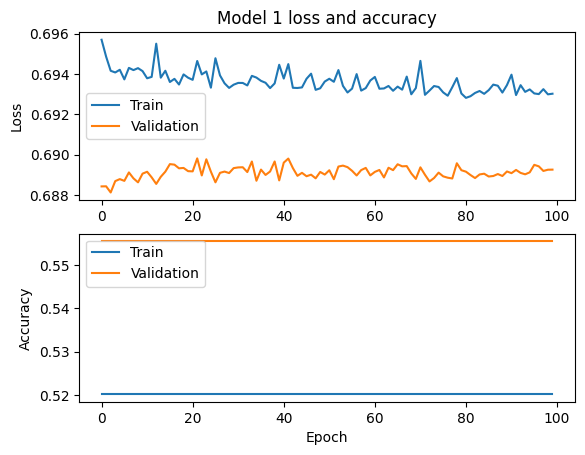

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, None, 10)       │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, None, 1)        │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - binary_accuracy: 0.4260 - loss: 0.7000
test accuracy: 0.5554732084274292


In [19]:
plotModelHistory(history,1)
model.summary()
test_loss, test_acc = model.evaluate(validationODG)
print("test accuracy: "+str(test_acc))

In [13]:
#Make a model that has multpile layers
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
inputList = [input1, input2]
inputs = tf.keras.layers.Concatenate()(inputList)
stack = tf.keras.layers.Dense(10,activation='relu')(inputs)
stack = tf.keras.layers.Dense(10)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model2 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
# callbacks=[]
# learningRates = [0.1,0.9,0.6,0.3,0.1,0.03,0.01,0.001,0.0001,0.00001,0.000001]
# callbacks.append(tf.keras.callbacks.LearningRateScheduler(lambda epoch,lr : lr if epoch<5 else lr*np.exp(-0.1)))
# callbacks=[]
history2 = model2.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=100)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - binary_accuracy: 0.5761 - loss: 0.6940 - val_binary_accuracy: 0.5779 - val_loss: 0.6897
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.6420 - loss: 0.6888 - val_binary_accuracy: 0.5641 - val_loss: 0.6857
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - binary_accuracy: 0.5645 - loss: 0.6878 - val_binary_accuracy: 0.6168 - val_loss: 0.6809
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.5931 - loss: 0.6846 - val_binary_accuracy: 0.6174 - val_loss: 0.6771
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.6130 - loss: 0.6757 - val_binary_accuracy: 0.6352 - val_loss: 0.6715
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - binary_accuracy: 0.6226 - loss: 0.6725 - val_binary_accuracy: 0.6400 - val_loss: 0.6653
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.6338 - loss: 0.6650 - val_binary_accuracy: 0.6551 - val_loss: 0.6571
Epoch 

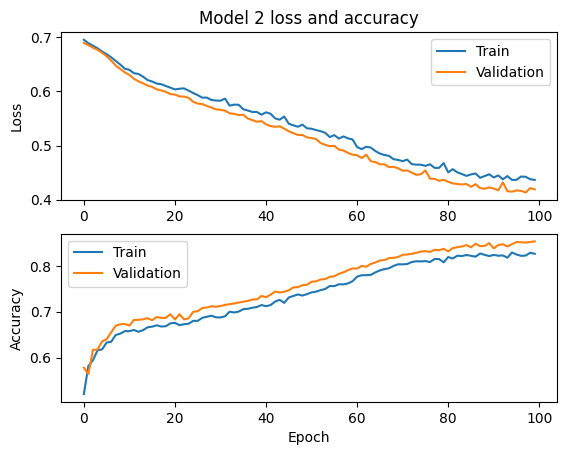

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ z_global            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x_size (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2)         │          0 │ z_global[0][0],   │
│ (Concatenate)       │                   │            │ x_size[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │         30 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │        110 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         11 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 455 (1.78 KB)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 304 (1.19 KB)

In [14]:
plotModelHistory(history2,2)
model2.summary()


In [10]:
#Make a model that has multpile layers
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
inputList = [input1, input2,input3,input4]
inputs = tf.keras.layers.Concatenate()(inputList)
stack = tf.keras.layers.Dense(10,activation='relu')(inputs)
stack = tf.keras.layers.Dense(10)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model3 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
# callbacks=[]
# learningRates = [0.1,0.9,0.6,0.3,0.1,0.03,0.01,0.001,0.0001,0.00001,0.000001]
# callbacks.append(tf.keras.callbacks.LearningRateScheduler(lambda epoch,lr : lr if epoch<5 else lr*np.exp(-0.1)))
# callbacks=[]
history3 = model3.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=150)

Epoch 1/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - binary_accuracy: 0.5327 - loss: 2.5470 - val_binary_accuracy: 0.4613 - val_loss: 1.2608
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - binary_accuracy: 0.4667 - loss: 1.2088 - val_binary_accuracy: 0.4803 - val_loss: 0.9969
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - binary_accuracy: 0.4873 - loss: 0.9593 - val_binary_accuracy: 0.5202 - val_loss: 0.8522
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - binary_accuracy: 0.4923 - loss: 0.8749 - val_binary_accuracy: 0.5476 - val_loss: 0.7892
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - binary_accuracy: 0.5169 - loss: 0.8105 - val_binary_accuracy: 0.5685 - val_loss: 0.7486
Epoch 6/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - binary_accuracy: 0.5211 - loss: 0.7914 - val_binary_accuracy: 0.5532 - val_loss: 0.7150
Epoch 7/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - binary_accuracy: 0.5522 - loss: 0.7179 - val_binary_accuracy: 0.5875 - val_loss: 0.6910
Epoch 

In [18]:
## here i will be making a 4-layer neural network 
## Model 1: z-global, x size, y size, y local


## define the inputs
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(1,), name="y_size")
input4 = tf.keras.layers.Input(shape=(1,), name="y_local")

## concatenate the inputs into one layer
inputList = [input1, input2, input3]
inputs = tf.keras.layers.Concatenate()(inputList)


## here i will add the layers 

stack1 = tf.keras.layers.Dense(10,activation='relu')(inputs)
stack2 = tf.keras.layers.Dense(10, activation='relu')(stack1)
stack3 = tf.keras.layers.Dense(10, activation='relu')(stack2)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack3)

ryan_model = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

ryan_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

history3 = ryan_model.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=150)



Epoch 1/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - binary_accuracy: 0.5404 - loss: 0.6897 - val_binary_accuracy: 0.5278 - val_loss: 0.6915
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - binary_accuracy: 0.5594 - loss: 0.6902 - val_binary_accuracy: 0.6084 - val_loss: 0.6874
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.5995 - loss: 0.6875 - val_binary_accuracy: 0.6218 - val_loss: 0.6842
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.6049 - loss: 0.6852 - val_binary_accuracy: 0.6288 - val_loss: 0.6819
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.5979 - loss: 0.6838 - val_binary_accuracy: 0.6329 - val_loss: 0.6773
Epoch 6/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.6137 - loss: 0.6783 - val_binary_accuracy: 0.6460 - val_loss: 0.6721
Epoch 7/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.6395 - loss: 0.6725 - val_binary_accuracy: 0.6549 - val_loss: 0.6670
Epoch 

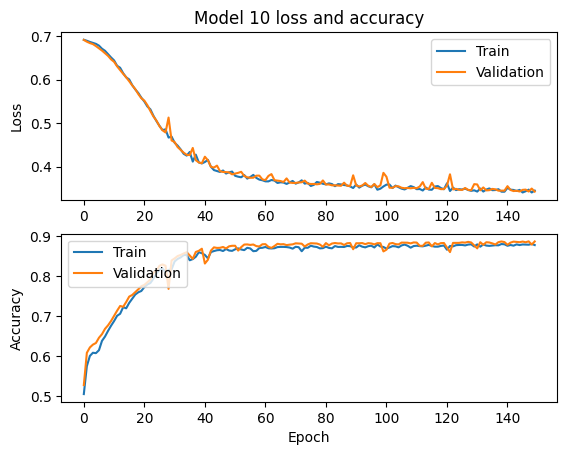

In [38]:
plotModelHistory(history3, 10)


In [36]:
## convolutional neural network
## Model 1: z-global, x size, y size, y local
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
input5 = tf.keras.layers.Input(shape=(13,21), name="cluster")
input6 = tf.keras.layers.Input(shape=(1,), name="y_global")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input5]
inputs = tf.keras.layers.Concatenate()(inputList)

stack1 = tf.keras.layers.Conv1D(32,(3),input_shape=(13,21))(inputs)
stack2 = tf.keras.layers.MaxPool1D((2))(stack1)
x =  tf.keras.layers.Flatten()(stack2)
y = tf.keras.layers.Concatenate()([x, input6]) 
stack5 = tf.keras.layers.Dense(10,activation='relu')(y)
stack6 = tf.keras.layers.Dense(10)(stack5)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack6)

ryan_model2 = tf.keras.Model(inputs=inputList, outputs=output)


ryan_model2 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

ryan_model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

history_ryan_model_2 = ryan_model.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=150)

Epoch 1/150


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - binary_accuracy: 0.8963 - loss: 0.3080 - val_binary_accuracy: 0.8902 - val_loss: 0.3220
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.8871 - loss: 0.3180 - val_binary_accuracy: 0.8907 - val_loss: 0.3191
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.8793 - loss: 0.3248 - val_binary_accuracy: 0.8907 - val_loss: 0.3207
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.8803 - loss: 0.3247 - val_binary_accuracy: 0.8912 - val_loss: 0.3206
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.8902 - loss: 0.3185 - val_binary_accuracy: 0.8919 - val_loss: 0.3193
Epoch 6/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.8757 - loss: 0.3293 - val_binary_accuracy: 0.8899 - val_loss: 0.3205
Epoch 7/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - binary_accuracy: 0.8949 - loss: 0.3066 - val_binary_accuracy: 0.8908 - val_loss: 0.3206
Epoch 8/150
60/60 

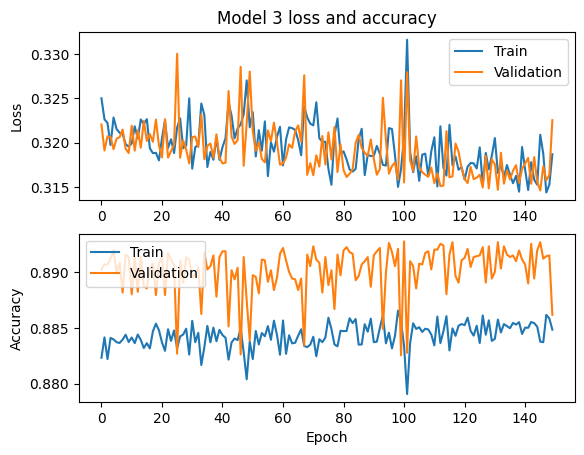

In [37]:
plotModelHistory(history_ryan_model_2,3)

In [12]:
test_loss, test_acc = model.evaluate(validationODG)
print("sequential model validation test accuracy: "+str(test_acc))

test_loss, test_acc = model2.evaluate(validationODG)
print("model2 validation test accuracy: "+str(test_acc))

test_loss, test_acc = model3.evaluate(validationODG)
print("model3 validation test accuracy: "+str(test_acc))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - binary_accuracy: 0.6107 - loss: 0.6620
sequential model validation test accuracy: 0.646705687046051
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - binary_accuracy: 0.8205 - loss: 0.4191
model2 validation test accuracy: 0.8535537123680115
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - binary_accuracy: 0.7868 - loss: 0.4603
model3 validation test accuracy: 0.8013784885406494


In [28]:

input5 = tf.keras.layers.Input(shape=(13,21), name="cluster")

input6 = tf.keras.layers.Input(shape=(1,), name="y_global")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input5]
inputs = tf.keras.layers.Concatenate()(inputList)
stack = tf.keras.layers.Conv1D(32,(3),input_shape=(13,21))(inputs)
stack = tf.keras.layers.Flatten()(stack)
stack = tf.keras.layers.Dense(10,activation='relu')(stack)
stack = tf.keras.layers.Dense(10)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model4 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
callbacks=[]
history4 = model4.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=100)


ValueError: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 13, 21), (None, 1)]

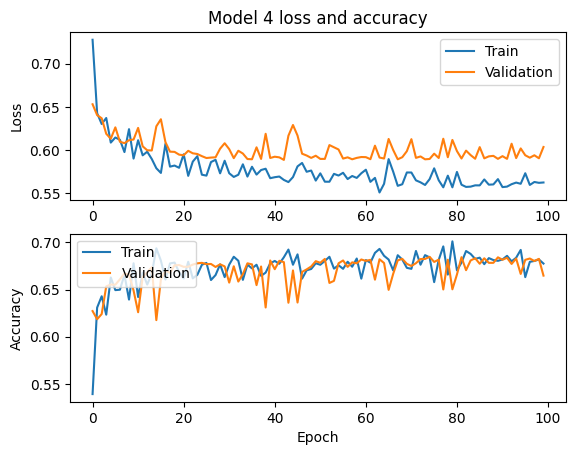

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - binary_accuracy: 0.6602 - loss: 0.5995
model4 validation test accuracy: 0.6647891402244568


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cluster (InputLayer)            │ (None, 13, 21)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_1 (Concatenate)     │ (None, 13, 21)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 11, 32)         │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         3,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,099 (66.80 KB)

 Trainable params: 5,699 (22.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,400 (44.54 KB)

In [8]:
plotModelHistory(history4, 4)
test_loss, test_acc = model4.evaluate(validationODG)
print("model4 validation test accuracy: "+str(test_acc))
model4.summary()

In [3]:
validation_dir = "./tf_records1000DanielWithTiming/tfrecords_validation/"
train_dir = "./tf_records1000DanielWithTiming/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster']
trainODG = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description,time_stamps=[17,18,19])
validationODG = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description,time_stamps=[17,18,19])
# trainODG._parse_tfrecord_fn()

In [20]:
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
input5 = tf.keras.layers.Input(shape=(13,21,3), name="cluster")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input5]
inputs = tf.keras.layers.Concatenate()(inputList)
stack = tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(13,21,3))(inputs)
stack = tf.keras.layers.MaxPool2D((2,2))(stack)
stack = tf.keras.layers.Conv2D(64,(3,3),activation='relu')(stack)
stack = tf.keras.layers.Flatten()(stack)
stack = tf.keras.layers.Dense(16,activation='relu')(stack)
stack = tf.keras.layers.Dense(16)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model5 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model5.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
callbacks=[]
history5 = model5.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=50)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50


ValueError: Exception encountered when calling Functional.call().

[1mInput 0 of layer "conv2d" is incompatible with the layer: expected axis -1 of input shape to have value 3, but received input with shape (None, 13, 21, 1)[0m

Arguments received by Functional.call():
  • inputs={'x_size': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'z_global': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'y_profile': 'tf.Tensor(shape=(None, 13), dtype=float32)', 'x_profile': 'tf.Tensor(shape=(None, 21), dtype=float32)', 'cluster': 'tf.Tensor(shape=(None, 13, 21, 1), dtype=float32)', 'y_size': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'y_local': 'tf.Tensor(shape=(None, 1), dtype=float32)'}
  • training=True
  • mask={'x_size': 'None', 'z_global': 'None', 'y_profile': 'None', 'x_profile': 'None', 'cluster': 'None', 'y_size': 'None', 'y_local': 'None'}
  • kwargs=<class 'inspect._empty'>

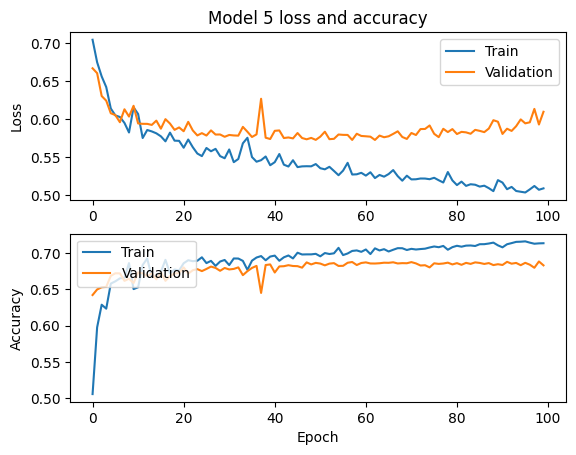

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - binary_accuracy: 0.6095 - loss: 0.6237
model5 validation test accuracy: 0.6829467415809631


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cluster (InputLayer)            │ (None, 13, 21, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate (Concatenate)       │ (None, 13, 21, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 11, 19, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 9, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1344)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        21,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,605 (482.84 KB)

 Trainable params: 41,201 (160.94 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82,404 (321.89 KB)

In [5]:
plotModelHistory(history5, 5)
test_loss, test_acc = model5.evaluate(validationODG)
print("model5 validation test accuracy: "+str(test_acc))
model5.summary()

Epoch 1/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - binary_accuracy: 0.3936 - loss: 0.8037 - val_binary_accuracy: 0.5135 - val_loss: 0.6903
Epoch 2/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - binary_accuracy: 0.5067 - loss: 0.6897 - val_binary_accuracy: 0.6603 - val_loss: 0.6703
Epoch 3/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - binary_accuracy: 0.6560 - loss: 0.6627 - val_binary_accuracy: 0.6532 - val_loss: 0.6465
Epoch 4/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - binary_accuracy: 0.6379 - loss: 0.6499 - val_binary_accuracy: 0.6431 - val_loss: 0.6583
Epoch 5/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - binary_accuracy: 0.6336 - loss: 0.6524 - val_binary_accuracy: 0.6366 - val_loss: 0.6581
Epoch 6/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - binary_accuracy: 0.5966 - loss: 0.6423 - val_binary_accuracy: 0.6571 - val_loss: 0.6440
Epoch 7/40
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - binary_accuracy: 0.6832 - loss: 0.6214 - val_binary_accuracy: 0.6768 - val_loss: 0.6197
Epoch 8/40
6

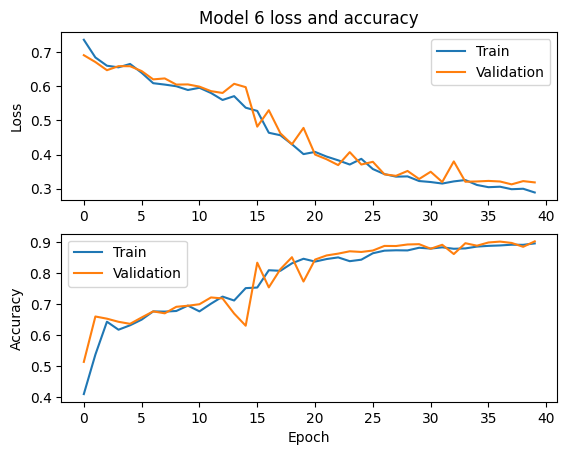

In [6]:
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
input5 = tf.keras.layers.Input(shape=(13,21,3), name="cluster")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input1, input5]
# inputs = tf.keras.layers.Concatenate()(inputList)
stackConv = tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(13,21,3))(input5)
stackConv = tf.keras.layers.MaxPool2D((2,2))(stackConv)
stackConv = tf.keras.layers.Conv2D(64,(3,3),activation='relu')(stackConv)
stackConv = tf.keras.layers.Flatten()(stackConv)
stackSingles = tf.keras.layers.Dense(16,activation='relu')(input1)
# stackSingles = tf.keras.layers.Flatten()(stackSingles)
stack = tf.keras.layers.Concatenate()([stackSingles,stackConv])
stack = tf.keras.layers.Dense(16,activation='relu')(stack)
stack = tf.keras.layers.Dense(16)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model6 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model6.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
callbacks = []
history6 = model6.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=40)
plotModelHistory(history6, 6)


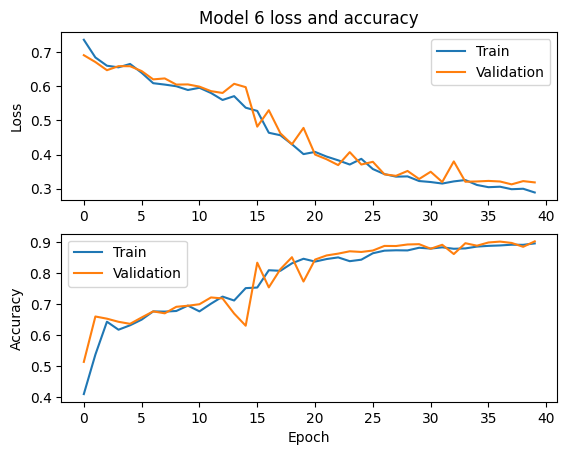

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - binary_accuracy: 0.8779 - loss: 0.3252
model6 validation test accuracy: 0.9031349420547485


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cluster             │ (None, 13, 21, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 11, 19,    │        896 │ cluster[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 5, 9, 32)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_global            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 3, 7, 64)  │     18,496 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │         32 │ z_global[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1344)      │          0 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1360)      │          0 │ dense_3[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │     21,776 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        272 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,469 (486.21 KB)

 Trainable params: 41,489 (162.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 82,980 (324.14 KB)

In [16]:
plotModelHistory(history6,6)
test_loss, test_acc = model6.evaluate(validationODG)
print("model6 validation test accuracy: "+str(test_acc))
model6.summary()

In [8]:
saveModels = False
if saveModels:
    filepath = "./DanielModels/model1.keras"
    model.save(filepath)
    filepath = "./DanielModels/model2.keras"
    model2.save(filepath)
    filepath = "./DanielModels/model3.keras"
    model3.save(filepath)
    filepath = "./DanielModels/model4.keras"
    model4.save(filepath)
    filepath = "./DanielModels/model5.keras"
    model5.save(filepath)
    filepath = "./DanielModels/model6.keras"
    model6.save(filepath)

In [15]:
validation_dir = "./tf_records3000DanielWithTiming/tfrecords_validation/"
train_dir = "./tf_records3000DanielWithTiming/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster']
trainODG7 = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description,time_stamps=[10,11,12,13,14,15,16,17,18,19])
validationODG7 = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description,time_stamps=[10,11,12,13,14,15,16,17,18,19])


In [16]:
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
input5 = tf.keras.layers.Input(shape=(13,21,10), name="cluster")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input1, input5]
# inputs = tf.keras.layers.Concatenate()(inputList)
stackConv = tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(13,21,10))(input5)
stackConv = tf.keras.layers.MaxPool2D((2,2))(stackConv)
stackConv = tf.keras.layers.Conv2D(64,(3,3),activation='relu')(stackConv)
stackConv = tf.keras.layers.Flatten()(stackConv)
stackSingles = tf.keras.layers.Dense(16,activation='relu')(input1)
# stackSingles = tf.keras.layers.Flatten()(stackSingles)
stack = tf.keras.layers.Concatenate()([stackSingles,stackConv])
stack = tf.keras.layers.Dense(16,activation='relu')(stack)
stack = tf.keras.layers.Dense(16)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model7 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()

model7.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
callbacks = []
history7 = model7.fit(x=trainODG7,validation_data=validationODG7, callbacks=callbacks,epochs=150)


Epoch 1/150


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - binary_accuracy: 0.6274 - loss: 0.9977 - val_binary_accuracy: 0.5604 - val_loss: 0.6793
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - binary_accuracy: 0.4868 - loss: 0.7051 - val_binary_accuracy: 0.6384 - val_loss: 0.6613
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - binary_accuracy: 0.6563 - loss: 0.6553 - val_binary_accuracy: 0.6265 - val_loss: 0.6420
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - binary_accuracy: 0.6099 - loss: 0.6722 - val_binary_accuracy: 0.6219 - val_loss: 0.6511
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - binary_accuracy: 0.6248 - loss: 0.6563 - val_binary_accuracy: 0.6472 - val_loss: 0.6443
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - binary_accuracy: 0.5540 - loss: 0.6774 - val_binary_accuracy: 0.6557 - val_loss: 0.6331
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - binary_accuracy: 0.6606 - loss: 0.6363 - val_binary_accuracy: 0.6257 - val_loss: 0.6316
Epoch 8/150
20/20

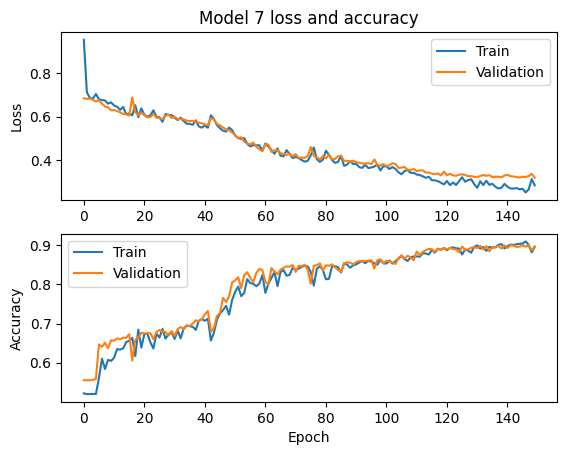

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - binary_accuracy: 0.8590 - loss: 0.3400
model7 validation test accuracy: 0.8967612981796265


In [19]:
plotModelHistory(history7,7)
test_loss, test_acc = model7.evaluate(validationODG7)
print("model7 validation test accuracy: "+str(test_acc))

In [3]:
validation_dir = "./tf_records3000DanielWith20Timing/tfrecords_validation/"
train_dir = "./tf_records3000DanielWith20Timing/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster']
trainODG8 = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description,time_stamps=list(range(20)))
validationODG8 = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description,time_stamps=list(range(20)))
nBatches=len([f for f in os.listdir(train_dir) if ".tfrecord" in f])
print(nBatches)


20


In [4]:
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
input5 = tf.keras.layers.Input(shape=(13,21,20), name="cluster")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input1, input5]
# inputs = tf.keras.layers.Concatenate()(inputList)
stackConv = tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(13,21,20))(input5)
stackConv = tf.keras.layers.MaxPool2D((2,2))(stackConv)
stackConv = tf.keras.layers.Conv2D(64,(3,3),activation='relu')(stackConv)
stackConv = tf.keras.layers.Flatten()(stackConv)
stackSingles = tf.keras.layers.Dense(16,activation='relu')(input1)
# stackSingles = tf.keras.layers.Flatten()(stackSingles)
stack = tf.keras.layers.Concatenate()([stackSingles,stackConv])
stack = tf.keras.layers.Dense(16,activation='relu')(stack)
stack = tf.keras.layers.Dense(16)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model8 = tf.keras.Model(inputs=inputList, outputs=output)

# model.summary()
#copied from Eliza's FilteringModel.py
learning_rate: float = 0.0001
nEpochs: int = 10
decay_steps = nEpochs*nBatches
warmup_steps = int(nEpochs*nBatches/10)
print(f"warmup steps: {warmup_steps}")
warmup_target = learning_rate
lr_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate/3, 
    decay_steps=decay_steps,
    warmup_steps=warmup_steps, 
    alpha=0.0, 
    # alpha=learning_rate/5, 
    warmup_target=warmup_target)

#from Eric's code
total_steps = decay_steps
# CosineDecay: initial_lr=1e-3, decay_steps=total_steps, alpha=0.0 (ends at 0)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=total_steps,
    alpha=0.0
)


#from Eliza's FilteringModel.py
# This just allows plotting the learning rate after training finishes
class LearningRate(tf.keras.callbacks.Callback):
    def __init__(self,schedule) -> None:
        super().__init__()
        self.schedule = schedule
        # self.model = modelIn

    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        logs['lr'] = lr
    
def scheduler(epoch, lr):
    print(f"epoch{epoch}")
    if epoch<80:
        print(lr)
        return 0.001
    elif epoch<120:
        return 0.0005
    else:
        print(lr)
        return 0.0001

# model8.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=((scheduler))), loss='binary_crossentropy', metrics=['binary_accuracy'])
model8.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
callbacks = [LearningRate(scheduler)]
callbacks = [tf.keras.callbacks.LearningRateScheduler(scheduler)]
# callbacks = []
history8 = model8.fit(x=trainODG8,validation_data=validationODG8, callbacks=callbacks,epochs=nEpochs,verbose=1)


/home/dabadjiev/.local/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-17 13:47:34.333163: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144


warmup steps: 20
epoch0
0.0010000000474974513
Epoch 1/10


I0000 00:00:1750186055.735078 1233225 service.cc:152] XLA service 0x7f4d3c00ec40 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750186055.735142 1233225 service.cc:160]   StreamExecutor device (0): Host, Default Version
2025-06-17 13:47:35.773019: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750186056.218306 1233225 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 763ms/step - binary_accuracy: 0.3277 - loss: 1.5183 - val_binary_accuracy: 0.5621 - val_loss: 0.6928 - learning_rate: 0.0010
epoch1
0.0010000000474974513
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 703ms/step - binary_accuracy: 0.5528 - loss: 0.6928 - val_binary_accuracy: 0.5834 - val_loss: 0.6905 - learning_rate: 0.0010
epoch2
0.0010000000474974513
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 724ms/step - binary_accuracy: 0.5452 - loss: 0.7006 - val_binary_accuracy: 0.6330 - val_loss: 0.6893 - learning_rate: 0.0010
epoch3
0.0010000000474974513
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 699ms/step - binary_accuracy: 0.6387 - loss: 0.6905 - val_binary_accuracy: 0.5582 - val_loss: 0.6913 - learning_rate: 0.0010
epoch4
0.0010000000474974513
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 693ms/step - binary_accuracy: 0.4805 - loss: 0.6943 - val_binary_accuracy: 0.5581 - val_loss: 0.6913 - learning_rate: 0.0010
epoch5
0.0010000000474974513
Epoch 6/10
20/20 ━━━━━━━━━━━━━━

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss', 'learning_rate'])
[0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.001000000

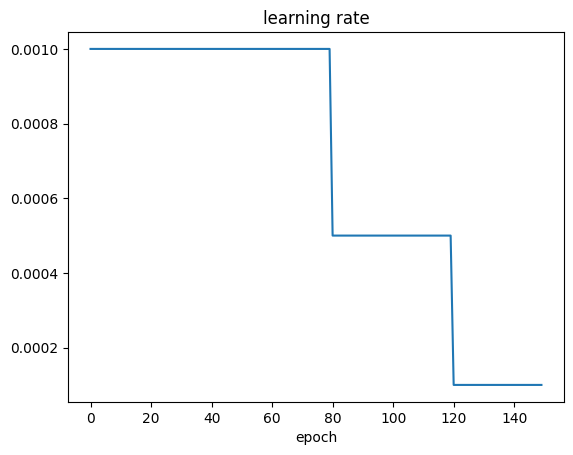

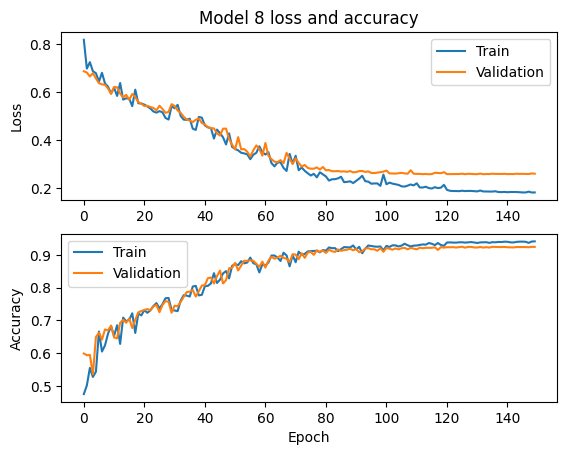

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - binary_accuracy: 0.9050 - loss: 0.2601
model8 validation test accuracy: 0.9249240159988403


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cluster             │ (None, 13, 21,    │          0 │ -                 │
│ (InputLayer)        │ 20)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 11, 19,    │      5,792 │ cluster[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 5, 9, 32)  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_global            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 3, 7, 64)  │     18,496 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ z_global[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1344)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1360)      │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │     21,776 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        272 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 139,157 (543.59 KB)

 Trainable params: 46,385 (181.19 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 92,772 (362.39 KB)

In [5]:
print(history8.history.keys())
if False:
    print(history8.history['lr'])
    print(np.size(history8.history['lr']))
    plt.plot(history8.history['lr'])
    plt.title("learning rate")
    plt.xlabel("epoch")
    plt.show()
if True:
    print(history8.history['learning_rate'])
    print(np.size(history8.history['learning_rate']))
    plt.plot(history8.history['learning_rate'])
    plt.title("learning rate")
    plt.xlabel("epoch")
    plt.show()
plotModelHistory(history8,8)
test_loss, test_acc = model8.evaluate(validationODG8)
print("model8 validation test accuracy: "+str(test_acc))
model8.summary()

In [ ]:
saveModels = False;
if saveModels:
    filepath = "./DanielModels/model7.keras"
    # model7.save(filepath)
    filepath = "./DanielModels/model8.keras"
    model8.save(filepath)

In [8]:
validation_dir = "./tf_records1000Daniel/tfrecords_validation/"
train_dir = "./tf_records1000Daniel/tfrecords_train/"
x_feature_description: list = ['x_size','z_global','y_profile','x_profile','cluster']
trainODG = OptimizedDataGenerator(tf_records_dir=train_dir,load_records=True, x_feature_description=x_feature_description)
validationODG = OptimizedDataGenerator(tf_records_dir=validation_dir,load_records=True, x_feature_description=x_feature_description)

In [ ]:
input1 = tf.keras.layers.Input(shape=(1,), name="z_global")
input2 = tf.keras.layers.Input(shape=(1,), name="x_size")
input3 = tf.keras.layers.Input(shape=(21,), name="x_profile")
input4 = tf.keras.layers.Input(shape=(13,), name="y_profile")
input5 = tf.keras.layers.Input(shape=(13,21,1), name="cluster")
# flatCluster = tf.keras.layers.Flatten()(input5)
inputList = [input1, input5]
# inputs = tf.keras.layers.Concatenate()(inputList)
stackConv = tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(13,21,1))(input5)
stackConv = tf.keras.layers.MaxPool2D((2,2))(stackConv)
stackConv = tf.keras.layers.Conv2D(64,(3,3),activation='relu')(stackConv)
stackConv = tf.keras.layers.Flatten()(stackConv)
stackSingles = tf.keras.layers.Dense(16,activation='relu')(input1)
# stackSingles = tf.keras.layers.Flatten()(stackSingles)
stack = tf.keras.layers.Concatenate()([stackSingles,stackConv])
stack = tf.keras.layers.Dense(16,activation='relu')(stack)
stack = tf.keras.layers.Dense(16)(stack)
output = tf.keras.layers.Dense(1,activation='sigmoid')(stack)

model9 = tf.keras.Model(inputs=inputList, outputs=output)
callbacks=[]
model9.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])
history9 = model9.fit(x=trainODG,validation_data=validationODG, callbacks=callbacks,epochs=100)

/home/dabadjiev/.local/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100


ValueError: Exception encountered when calling Functional.call().

[1mInput 0 of layer "conv2d_8" is incompatible with the layer: expected axis -1 of input shape to have value 20, but received input with shape (None, 13, 21, 1)[0m

Arguments received by Functional.call():
  • inputs={'x_size': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'z_global': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'y_profile': 'tf.Tensor(shape=(None, 13), dtype=float32)', 'x_profile': 'tf.Tensor(shape=(None, 21), dtype=float32)', 'cluster': 'tf.Tensor(shape=(None, 13, 21, 1), dtype=float32)'}
  • training=True
  • mask={'x_size': 'None', 'z_global': 'None', 'y_profile': 'None', 'x_profile': 'None', 'cluster': 'None'}
  • kwargs=<class 'inspect._empty'>

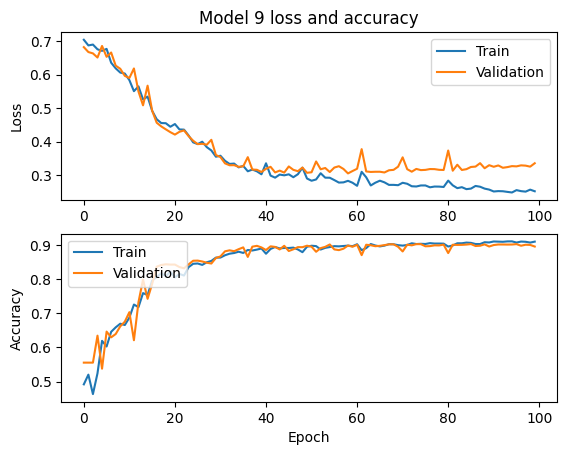

ValueError: Exception encountered when calling Functional.call().

[1mInput 0 of layer "conv2d_8" is incompatible with the layer: expected axis -1 of input shape to have value 20, but received input with shape (None, 13, 21, 1)[0m

Arguments received by Functional.call():
  • inputs={'x_size': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'z_global': 'tf.Tensor(shape=(None, 1), dtype=float32)', 'y_profile': 'tf.Tensor(shape=(None, 13), dtype=float32)', 'x_profile': 'tf.Tensor(shape=(None, 21), dtype=float32)', 'cluster': 'tf.Tensor(shape=(None, 13, 21, 1), dtype=float32)'}
  • training=False
  • mask={'x_size': 'None', 'z_global': 'None', 'y_profile': 'None', 'x_profile': 'None', 'cluster': 'None'}
  • kwargs=<class 'inspect._empty'>

In [13]:
if False:
    print(history9.history['learning_rate'])
    print(np.size(history9.history['learning_rate']))
    plt.plot(history9.history['learning_rate'])
    plt.title("learning rate")
    plt.xlabel("epoch")
    plt.show()
plotModelHistory(history9,9)
test_loss, test_acc = model9.evaluate(validationODG)
print("model9 validation test accuracy: "+str(test_acc))
model9.summary()